# Climate Change Responsibility Analysis

### Research Question
How financing flows vary geographically, and examine the **alignment** of these flows with:
1. Climate vulnerability to funding recipient,
2. GHGs emission to funding contributor

## Packages and Imports

In [6]:
# #Installs
# !pip install geodatasets
# !pip install pycountry
# !pip install country_converter --upgrade
# !pip install plotly.express
# !pip install mplcursors
# !pip install matplotlib ipywidgets

In [7]:
#import packages and settings
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import xarray as xr
import geopandas as gpd
import geodatasets as geo
import country_converter as coco
import plotly.io as pio
import mplcursors
from ipywidgets import interact
pio.renderers.default = 'notebook_connected'
cc = coco.CountryConverter()

#set parameters
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [8]:
#import data
pledges_df = pd.read_csv("https://github.com/siddharthgundala/Final-Project/raw/refs/heads/main/Pledges.csv",encoding="ISO-8859-1", sep=';')
funds_df = pd.read_csv("https://github.com/siddharthgundala/Final-Project/raw/refs/heads/main/Fund%20Status.csv",encoding="ISO-8859-1", sep=';')
projects_df = pd.read_csv("https://github.com/siddharthgundala/Final-Project/raw/refs/heads/main/Projects.csv",encoding="ISO-8859-1", sep=';')
co2_df = pd.read_csv("https://github.com/siddharthgundala/Final-Project/raw/refs/heads/main/annual-co2-emissions-per-country.csv")
methane_df = pd.read_csv("https://github.com/siddharthgundala/Final-Project/raw/refs/heads/main/methane-emissions.csv")
cfvi_df= pd.read_csv("https://github.com/siddharthgundala/Final-Project/raw/refs/heads/main/CFVI.csv")

In [9]:
#quick checks
print("Shapes:", pledges_df.shape, funds_df.shape, projects_df.shape,
      co2_df.shape, methane_df.shape, cfvi_df.shape)
print("Columns:", pledges_df.columns, funds_df.columns, projects_df.columns,
      co2_df.columns, methane_df.columns, cfvi_df.columns)

Shapes: (1257, 13) (31, 8) (3800, 25) (29137, 4) (37410, 4) (188, 3)
Columns: Index(['Fund', 'Fund Type', 'Fund focus', 'Contributor', 'Country',
       'Country Income Level', 'Region', 'Pledged (USD million current)',
       'Deposited (USD million current)', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12'],
      dtype='object') Index(['Fund', 'Fund Type', 'Fund focus', 'Pledge (USD mn)',
       'Deposit (USD mn)', 'Approval (USD mn)', 'Disbursement (USD mn)',
       'Number of projects approved'],
      dtype='object') Index(['Fund', 'Fund Type', 'Country', 'World Bank Region',
       'Income Classification', 'Name of Project', 'Theme/Objective',
       'Sector (OECD)', 'DAC 5 Code', 'Sub-Sector', 'Key words',
       'Implementing Agency', 'Recipient Institution',
       'Recipient Institution type', 'Approved year', 'End year',
       'Concessional loan', 'Grant', 'Guarantee', 'Equity',
       'Amount of Funding Approved (USD millions)',
       ' Disbursed (USD mi

## Data cleaning

### Emission - CO2 & CH4
Goal: Merge and Rename 

In [10]:
#emissions_df

In [11]:
#create total historical emissions
co2_total = (
    co2_df.groupby('Entity')['Annual CO₂ emissions']
          .sum(min_count=1)
          .reset_index()
          .rename(columns={'Annual CO₂ emissions': 'Total_CO2_emissions',})
)
print(co2_total.shape)


(247, 2)


In [12]:
#create total historical emissions
methane_total = (
    methane_df.groupby('Entity')['Annual methane emissions in CO₂ equivalents']
              .sum(min_count=1)
              .reset_index()
              .rename(columns={'Annual methane emissions in CO₂ equivalents': 'Total_Methane_emissions'
              })
)
print(methane_total.shape)

(215, 2)


In [13]:
#merge CO2 and methane into emissions_df
emissions_df = pd.merge(co2_total, methane_total, on='Entity', how='outer')

emissions_df.fillna(0, inplace=True)

In [14]:
#sum columns to create total historical emissions by entity (CO2e)
emissions_df['Total_GHG_CO2e'] = (emissions_df['Total_CO2_emissions'] + emissions_df['Total_Methane_emissions']
)

print(emissions_df.shape)
emissions_df.head()

(249, 4)


,Entity,Total_CO2_emissions,Total_Methane_emissions,Total_GHG_CO2e
0,Afghanistan,2.368414e+08,1.404239e+09,1.641080e+09
1,Africa,5.259617e+10,8.047920e+10,1.330754e+11
2,Africa (GCP),5.259576e+10,0.000000e+00,5.259576e+10
3,Albania,3.041735e+08,3.365854e+08,6.407589e+08
4,Algeria,5.263690e+09,4.756343e+09,1.002003e+10


### Finance – Climate Funds (Pledge & Receipt) & Financial Vulnerability
Goal: Country name matching, Funding merge by Country

In [15]:
# pledges_by_ctry and receipts_by_ctry

In [16]:
#rename columns for clarity
pledges_df = pledges_df.rename(columns={
    'Pledged (USD million current)': 'pledged_usd_million'
})
projects_df = projects_df.rename(columns={
    'Amount of Funding Approved (USD millions)': 'approved_usd_million'
})

In [17]:
#known issue wth two empty cells in projects_df
print(projects_df[projects_df['approved_usd_million'].isna()])

                                                  Fund     Fund Type  Country  \
900  Adaptation for Smallholder Agriculture Program...  Multilateral  Somalia   
901  Adaptation for Smallholder Agriculture Program...  Multilateral    Yemen   

              World Bank Region Income Classification  \
900          Sub-Saharan Africa            Low income   
901  Middle East & North Africa            Low income   

                                       Name of Project Theme/Objective  \
900  Adaptive Agriculture and Rangeland Rehabilitat...      Adaptation   
901        Rural Livelihood Development Project (RLDP)      Adaptation   

    Sector (OECD) DAC 5 Code  \
900   Agriculture    DAC311_   
901   Agriculture    DAC311_   

                                            Sub-Sector  ... End year  \
900  Agricultural policy and administrative management  ...      NaN   
901                           Agricultural development  ...      NaN   

    Concessional loan Grant Guarantee  Equity a

In [18]:
#quick fix as values should be "7" instead of empty
projects_df.loc[
    projects_df['approved_usd_million'].isna(),
    'approved_usd_million'
] = 7

In [19]:
#replace "," with "."

pledges_df['pledged_usd_million']  = pledges_df['pledged_usd_million'].astype(str).str.replace(',', '.', regex=False)
projects_df['approved_usd_million'] = projects_df['approved_usd_million'].astype(str).str.replace(',', '.', regex=False)

In [20]:
#convert strings into floats
pledges_df['pledged_usd_million']  = pd.to_numeric(pledges_df['pledged_usd_million'],  errors='coerce')
projects_df['approved_usd_million'] = pd.to_numeric(projects_df['approved_usd_million'], errors='coerce')

In [21]:
#sum by country

pledges_by_ctry = (
    pledges_df
      .groupby('Country', as_index=False)['pledged_usd_million']
      .sum()
)
receipts_by_ctry = (
    projects_df
      .groupby('Country', as_index=False)['approved_usd_million']
      .sum()
)
print(pledges_by_ctry.shape)
print(receipts_by_ctry.shape)
print(pledges_by_ctry.head())
print(receipts_by_ctry.head())

(70, 2)
(329, 2)
      Country  pledged_usd_million
0   Australia               606.08
1     Austria               499.54
2  Bangladesh                 0.05
3     Belgium               912.32
4      Brazil                17.54
               Country  approved_usd_million
0          Afghanistan                 65.24
1              Albania                 36.98
2              Algeria                  9.65
3               Angola                 49.91
4  Antigua and Barbuda                 58.96


In [22]:
#vulnerability_df

In [23]:
cfvi_df = cfvi_df.rename(columns={'Index Score': 'CFVI_score'})

vulnerability_df = cfvi_df[['Country', 'CFVI_score']]


In [24]:
# filters for pledges and receipts
country_master    = cc.data
valid_iso2        = set(country_master['ISO2'].dropna())
valid_iso3        = set(country_master['ISO3'].dropna())
valid_name_short  = set(country_master['name_short'].dropna())
valid_official    = set(country_master['name_official'].dropna())
valid_labels      = valid_iso2.union(valid_iso3, valid_name_short, valid_official)

def filter_and_iso3(df, country_col, amount_cols):
    df_clean = df[df[country_col].isin(valid_labels)].copy()
    df_clean['country_iso3'] = cc.pandas_convert(
        series = df_clean[country_col],
        to     = 'ISO3'
    )
    df_clean = df_clean[df_clean['country_iso3'] != 'not found']
    return df_clean[['country_iso3'] + amount_cols]

pledges_iso = filter_and_iso3(
    pledges_by_ctry,
    country_col = 'Country',
    amount_cols = ['pledged_usd_million']
)

receipts_iso = filter_and_iso3(
    receipts_by_ctry,
    country_col = 'Country',
    amount_cols = ['approved_usd_million']
)


emissions_df['country_iso3'] = cc.pandas_convert(
    series = emissions_df['Entity'],
    to     = 'ISO3'
)

#drop lists of countrys such as "More than one regular expression match for Asia (excl. China and India)"
emissions_iso = (
    emissions_df
      # keep only scalar strings that mapped successfully
      .loc[
          emissions_df['country_iso3'].apply(lambda x: isinstance(x, str))
        & (emissions_df['country_iso3'] != 'not found'),
          ['country_iso3','Total_GHG_CO2e']
      ]
      .copy()
)

# straight convert for vulnerability
vulnerability_df['country_iso3'] = cc.pandas_convert(
    series = vulnerability_df['Country'],
    to     = 'ISO3'
)

print("pledges:",    pledges_by_ctry.shape, "→", pledges_iso.shape)
print("receipts:",   receipts_by_ctry.shape,"→", receipts_iso.shape)
print("emissions:",  emissions_df.shape,    "→", emissions_iso.shape)
print("vulnerability:", vulnerability_df.shape)

Africa not found in regex
Africa (GCP) not found in regex
Asia not found in regex
Asia (GCP) not found in regex
More than one regular expression match for Asia (excl. China and India)
More than one regular expression match for Asia (excl. China and India)
More than one regular expression match for Asia (excl. China and India)
More than one regular expression match for Asia (excl. China and India)
More than one regular expression match for Asia (excl. China and India)
More than one regular expression match for Asia (excl. China and India)
More than one regular expression match for Asia (excl. China and India)
More than one regular expression match for Asia (excl. China and India)
More than one regular expression match for Asia (excl. China and India)
More than one regular expression match for Asia (excl. China and India)
More than one regular expression match for Asia (excl. China and India)
More than one regular expression match for Asia (excl. China and India)
More than one regular ex

pledges: (70, 2) → (58, 2)
receipts: (329, 2) → (143, 2)
emissions: (249, 5) → (217, 2)
vulnerability: (188, 3)


### Build a Master dataframe
Goal: Merge all dfs

In [20]:
#Building master_df

In [21]:
#create copy of vuln_df to build master_df
master_df = vulnerability_df[['country_iso3','CFVI_score']].copy()

#merge with emissions
master_df = master_df.merge(
    emissions_iso[['country_iso3','Total_GHG_CO2e']],
    on='country_iso3',
    how='left'
)

master_df = master_df.merge(
    pledges_iso[['country_iso3','pledged_usd_million']],
    on='country_iso3',
    how='left'
)

master_df = master_df.merge(
    receipts_iso[['country_iso3','approved_usd_million']],
    on='country_iso3',
    how='left'
)


In [22]:
# 1) Basic structure
print("Shape:", master_df.shape)
print(master_df.info(), "\n")

# 2) Peek at the data
print(master_df.head(), "\n")

# 3) Check for duplicate countries
dup_count = master_df['country_iso3'].duplicated().sum()
print("Duplicate ISO3 codes:", dup_count, "\n")

# 4) Missing values per column
print("Missing values:\n", master_df.isnull().sum(), "\n")

Shape: (189, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country_iso3          189 non-null    object 
 1   CFVI_score            189 non-null    float64
 2   Total_GHG_CO2e        189 non-null    float64
 3   pledged_usd_million   56 non-null     float64
 4   approved_usd_million  141 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.5+ KB
None 

  country_iso3  CFVI_score  Total_GHG_CO2e  pledged_usd_million  \
0          GNB        90.9    1.225099e+08                  NaN   
1          ERI        89.2    2.586003e+08                  NaN   
2          AGO        87.7    3.510466e+09                  NaN   
3          ZMB        86.4    1.292925e+09                  NaN   
4          PSE        85.8    7.079179e+07                  NaN   

   approved_usd_million  
0                 60.12  
1        

In [23]:
# inspect the duplicate
dupe_codes = master_df.loc[
    master_df['country_iso3'].duplicated(keep=False),
    'country_iso3'
].unique()

print("Duplicated ISO3 codes:", dupe_codes)

for code in dupe_codes:
    print(f"\nRows for {code}:")
    print(master_df[master_df['country_iso3'] == code])

Duplicated ISO3 codes: ['KWT']

Rows for KWT:
    country_iso3  CFVI_score  Total_GHG_CO2e  pledged_usd_million  \
150          KWT        35.4    5.798820e+09                  NaN   
151          KWT        35.4    4.779248e+08                  NaN   

     approved_usd_million  
150                  0.85  
151                  0.85  


In [24]:
#Drop duplicate 
master_df = master_df.drop_duplicates(subset='country_iso3')

#check
print(master_df.shape)

(188, 5)


In [25]:
# handling missing values 
master_df.fillna(
    {'pledged_usd_million': 0, 'approved_usd_million': 0},
    inplace=True
)

In [26]:
#Add back a Country Column 
master_df['Country'] = cc.convert(names=master_df['country_iso3'], to='name_short')

In [27]:
#quick checks
print("Shapes:", master_df.shape)
print("Columns:", master_df.columns)

Shapes: (188, 6)
Columns: Index(['country_iso3', 'CFVI_score', 'Total_GHG_CO2e', 'pledged_usd_million',
       'approved_usd_million', 'Country'],
      dtype='object')


In [28]:
# Export master_df to CSV
#master_df.to_csv('master_df.csv', index=False)

# Data Visualizations


### I- Climate Finance Vulnerability Map

Chloropleth was used as a baseline visualization, then package "ployly" was intergrate 

In [29]:
# import map file 
world = gpd.read_file('https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/all_world.geojson')

print(world.columns)

Index(['name', 'geometry'], dtype='object')


In [30]:
#convert country name column to ISO3
world['country_iso3'] = cc.pandas_convert(
    series = world['name'],
    to     = 'ISO3'
)

Fr. S. Antarctic Lands not found in regex
S. Sudan not found in regex


In [31]:
#merge world and master_df

world_merged = world.merge(
    master_df,
    on = 'country_iso3',
    how = 'left'
)

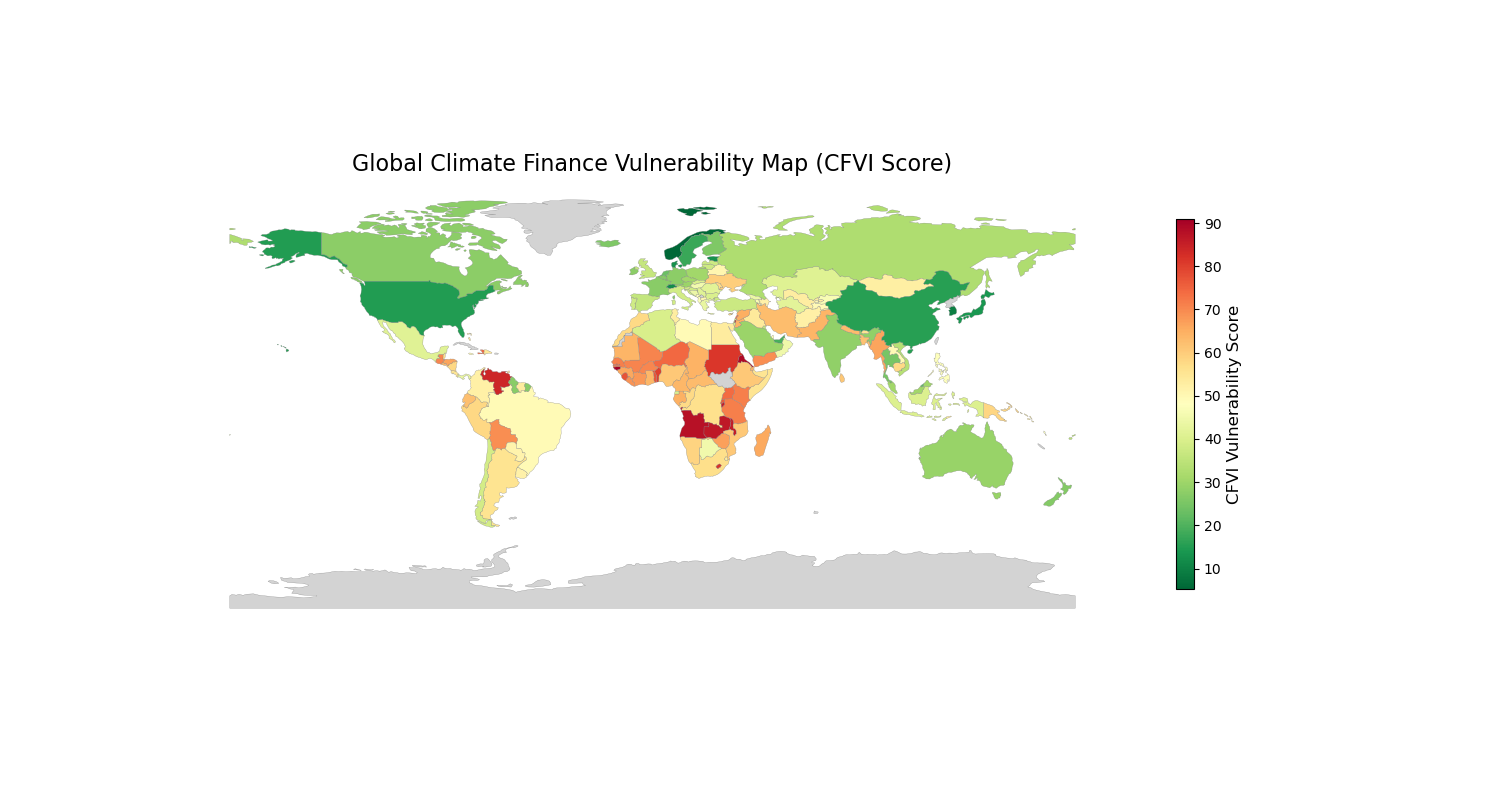

In [32]:
#plot chloropleth map (matplotlib)


fig, ax = plt.subplots(1, 1, figsize=(15, 8))
world_merged.plot(
    column       = 'CFVI_score',
    cmap         = 'RdYlGn_r',
    linewidth    = 0.2,
    edgecolor    = 'gray',
    missing_kwds = {
        "color": "lightgray",
        "label": "No data"
    },
    legend       = True,
    legend_kwds  = {
        "label": "CFVI Vulnerability Score",
        "shrink": 0.6
    },
    ax           = ax
)
ax.set_title("Global Climate Finance Vulnerability Map (CFVI Score)", fontsize=16)
ax.set_axis_off()
plt.show()

In [33]:
#plot chloropleth map (plotly)

fig = px.choropleth(
    master_df,
    locations='country_iso3',      
    color='CFVI_score',            
    hover_name='Country',          
    color_continuous_scale='RdYlGn_r', 
    range_color=[master_df['CFVI_score'].min(), master_df['CFVI_score'].max()],
    labels={'CFVI_score': 'CFVI Score'},
    title='Global Climate Vulnerability by Country'
)

#layout
fig.update_geos(
    showcoastlines=True,
    showland=True,
    fitbounds="locations",
    projection_type="robinson"
)
fig.update_layout(
    margin={"r":0,"t":40,"l":0,"b":0},
    coloraxis_colorbar=dict(
        title="CFVI Score",
        x=1.05,       # shift it right
        thickness=20,
        len=0.8
    )
)

fig.show()

### II- Scatter Plots

#### II-A Emissions vs. Vulnerability Scatter Plot

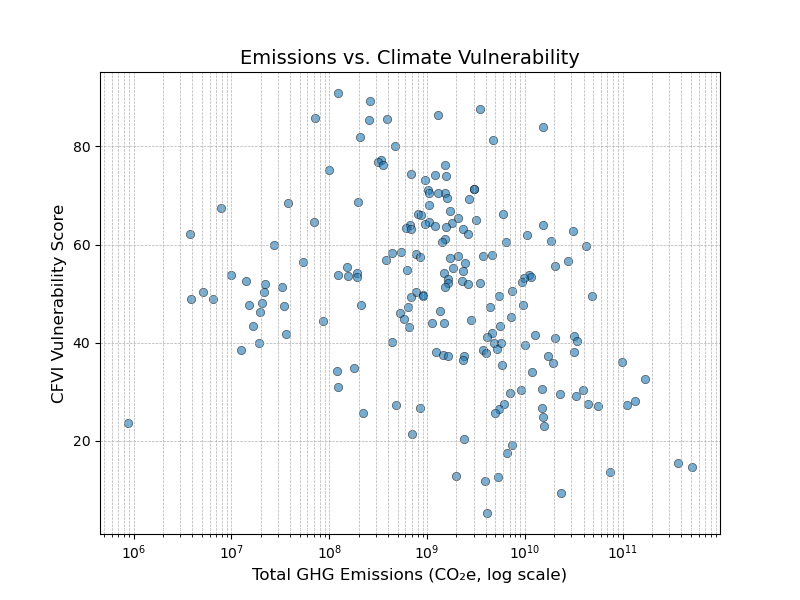

In [34]:
#using matplotlib
df = master_df.dropna(subset=['Total_GHG_CO2e','CFVI_score','Country'])
x = df['Total_GHG_CO2e']
y = df['CFVI_score']
labels = df['Country']

# Create interactive scatter
fig, ax = plt.subplots(figsize=(8,6))
sc = ax.scatter(x, y, alpha=0.6, edgecolor='k', linewidth=0.5)
ax.set_xscale('log')
ax.set_xlabel('Total GHG Emissions (CO₂e, log scale)')
ax.set_ylabel('CFVI Vulnerability Score')
ax.set_title('Emissions vs. Climate Vulnerability')
ax.grid(True, which="both", ls="--", lw=0.5)

# Enable hover annotations
cursor = mplcursors.cursor(sc, hover=True)
@cursor.connect("add")
def on_add(sel):
    sel.annotation.set_text(labels.iloc[sel.index])
    sel.annotation.get_bbox_patch().set(alpha=0.8)

plt.show()

In [35]:
#using plotly
df2 = master_df.dropna(subset=['Total_GHG_CO2e','CFVI_score','Country'])

fig1 = px.scatter(
    df2,
    x='Total_GHG_CO2e',
    y='CFVI_score',
    hover_name='Country',
    log_x=True,
    labels={
        'Total_GHG_CO2e': 'Total GHG Emissions (CO₂e)',
        'CFVI_score':     'Vulnerability Score'
    },
    title='Emissions vs. Climate Vulnerability'
)

fig1.update_traces(marker=dict(size=8, opacity=0.7, line=dict(width=0.5, color='DarkSlateGrey')))
fig1.update_layout(
    xaxis_title="Total GHG Emissions (CO₂e, log scale)",
    yaxis_title="CFVI Vulnerability Score",
    margin=dict(l=40, r=40, t=60, b=40)
)

fig1.show()


#### II-B Received Funding vs. Vulnerability Scatter Plot

In [42]:
#Climate Finance Vulnerability vs. Received Funding scatterplot (plotly)

fig = px.scatter(
    master_df,
    x='approved_usd_million',
    y='CFVI_score',
    hover_name='Country',
    log_x=True, #SHOULD WE KEEP THIS LOG SCALE?
    labels={
        'approved_usd_million': 'Received Funding (USD million)',
        'CFVI_score': 'Vulnerability Score'
    },
    title='Climate Finance Vulnerability vs. Received Funding'
)

fig.update_traces(
    marker=dict(size=8, opacity=0.7, line=dict(width=0.5, color='DarkSlateGrey'))
)

fig.update_layout(
    xaxis_title="Approved Funding (USD million)",
    yaxis_title="CFVI Vulnerability Score",
    margin=dict(l=40, r=40, t=60, b=40)
)

fig.show()

#### II-C Pledged Funding vs. Emissions

In [37]:
#MAYBE DROP THIS??

df3 = master_df.dropna(subset=['pledged_usd_million', 'Total_GHG_CO2e', 'Country']).copy()
df3 = df3[df3['pledged_usd_million'] > 0]

fig = px.scatter(
    df3,
    x='Total_GHG_CO2e',
    y='pledged_usd_million',
    hover_name='Country',
    log_x=True,
    labels={
        'Total_GHG_CO2e': 'Total GHG Emissions (CO₂e, log scale)',
        'pledged_usd_million': 'Pledged Funding (USD million)'
    },
    title='Pledged Climate Funding vs. Historical GHG Emissions'
)


fig.update_traces(
    marker=dict(size=8, opacity=0.7, line=dict(width=0.5, color='DarkSlateGrey'))
)

fig.update_layout(
    margin=dict(l=40, r=40, t=60, b=40),
    xaxis_title="Total GHG Emissions (CO₂e, log scale)",
    yaxis_title="Pledged Funding (USD million)"
)

fig.show()

### III- Correlation Heatmap

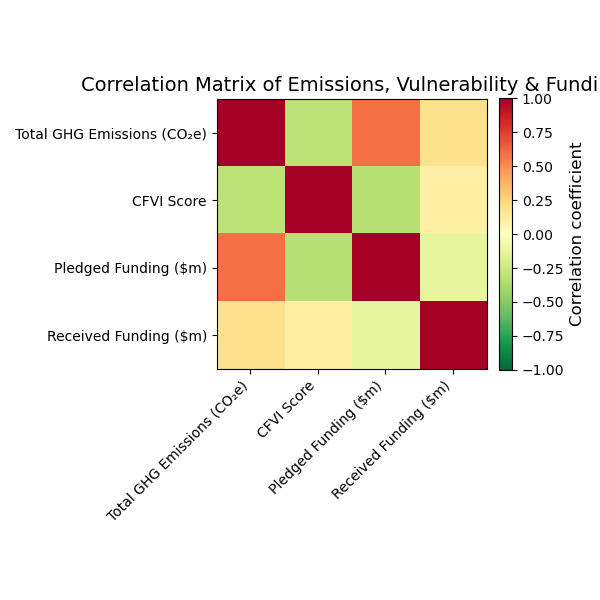

In [44]:
#compute the correlation matrix (matplotlib)

cols = ['Total_GHG_CO2e', 'CFVI_score', 'pledged_usd_million', 'approved_usd_million']
corr = master_df[cols].corr()

pretty_labels = [
    'Total GHG Emissions (CO₂e)',
    'CFVI Score',
    'Pledged Funding ($m)',
    'Received Funding ($m)'
]


fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(
    corr.values,
    cmap='RdYlGn_r',  
    vmin=-1, vmax=1
)

ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(cols)))
ax.set_xticklabels(pretty_labels, rotation=45, ha='right')
ax.set_yticklabels(pretty_labels)

#colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation coefficient')


ax.set_title('Correlation Matrix of Emissions, Vulnerability & Funding')
plt.tight_layout()
plt.show()

In [43]:
#compute the correlation matrix (plotly)

cols = ['Total_GHG_CO2e', 'CFVI_score', 'pledged_usd_million', 'approved_usd_million']
corr = master_df[cols].corr()

fig = px.imshow(
    corr,
    x=pretty_labels,
    y=pretty_labels,
    color_continuous_scale='RdYlGn_r',
    zmin=-1, zmax=1,
    labels={'color': 'Correlation'},
    title='Correlation Matrix: Emissions, Vulnerability & Funding'
)


fig.update_layout(
    width=600,
    height=600,
    margin=dict(l=40, r=40, t=60, b=40),
    coloraxis_colorbar=dict(
        x=1.2,      
        thickness=20,
        len=0.7      
    )
)

fig.update_xaxes(side="bottom")

fig.show()

### IV- Funding vs. GHG Emissions Equity Plots

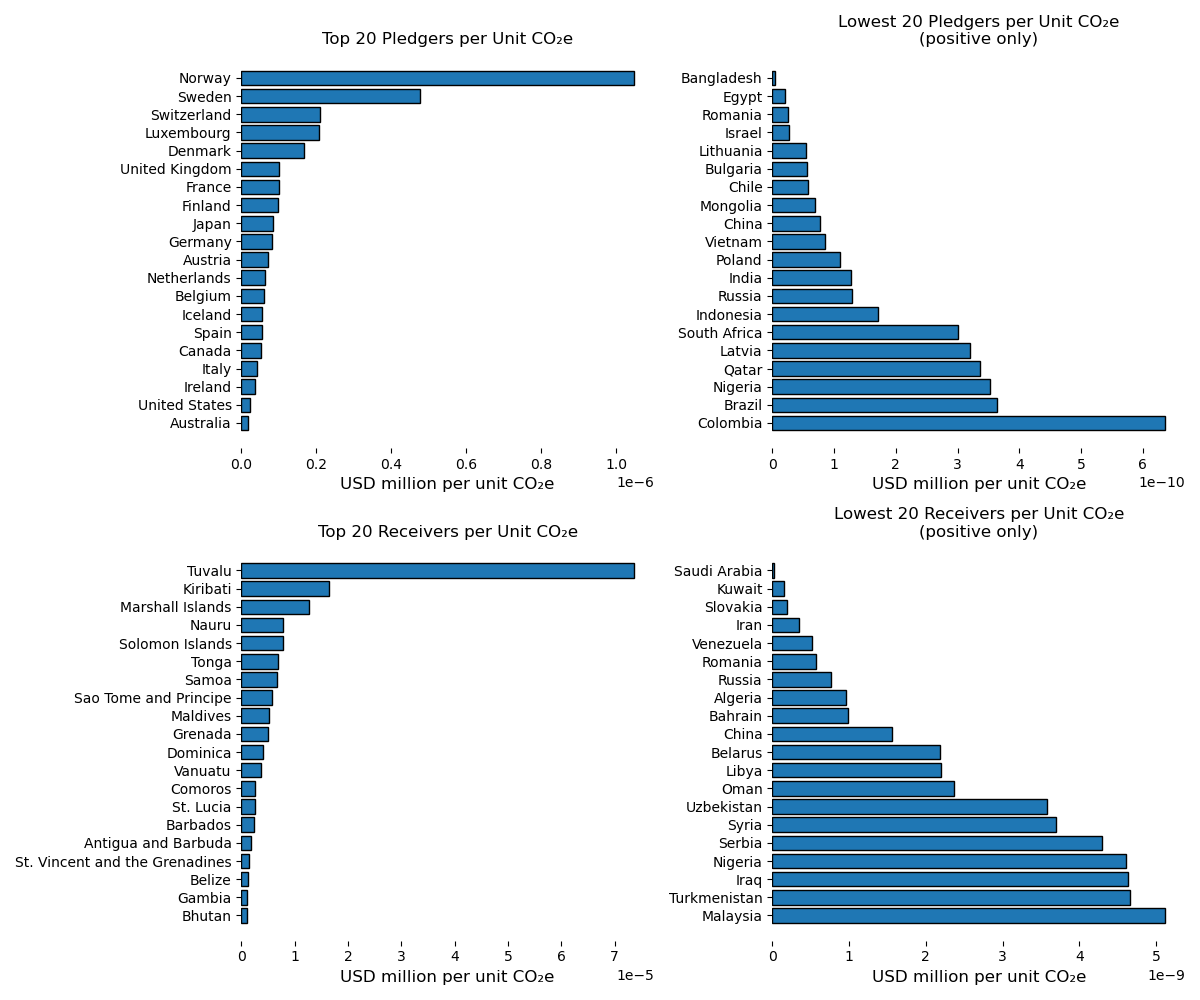

Dropped 132 countries with zero pledges
Dropped 48 countries with zero approvals


In [48]:
master_df['pledge_per_co2e']   = master_df['pledged_usd_million']   / master_df['Total_GHG_CO2e']
master_df['approved_per_co2e'] = master_df['approved_usd_million'] / master_df['Total_GHG_CO2e']

#Filter countries with O pledged or received
df_pledges_nz  = master_df[master_df['pledged_usd_million']  > 0].dropna(subset=['pledge_per_co2e'])
df_approved_nz = master_df[master_df['approved_usd_million'] > 0].dropna(subset=['approved_per_co2e'])

#top/bottom N among those with positive funding
N = 20

top_pledgers    = df_pledges_nz.nlargest(N, 'pledge_per_co2e')
bottom_pledgers = df_pledges_nz.nsmallest(N, 'pledge_per_co2e')

top_receivers    = df_approved_nz.nlargest(N, 'approved_per_co2e')
bottom_receivers = df_approved_nz.nsmallest(N, 'approved_per_co2e')


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

#define the plot
def hbar(ax, data, col, title, xlabel):
    ax.barh(
        data['Country'],
        data[col],
        color='C0',
        edgecolor='k'
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)
    # ax.set_xlim(0,6*1e-5)
    ax.invert_yaxis() 
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

#plot
hbar(
    axes[0],
    top_pledgers,
    'pledge_per_co2e',
    f"Top {N} Pledgers per Unit CO₂e",
    "USD million per unit CO₂e"
)
hbar(
    axes[1],
    bottom_pledgers,
    'pledge_per_co2e',
    f"Lowest {N} Pledgers per Unit CO₂e\n(positive only)",
    "USD million per unit CO₂e"
)
hbar(
    axes[2],
    top_receivers,
    'approved_per_co2e',
    f"Top {N} Receivers per Unit CO₂e",
    "USD million per unit CO₂e"
)
hbar(
    axes[3],
    bottom_receivers,
    'approved_per_co2e',
    f"Lowest {N} Receivers per Unit CO₂e\n(positive only)",
    "USD million per unit CO₂e"
)

plt.tight_layout()
plt.show()

# report dropped countries because 0 funding
print(f"Dropped {len(master_df) - len(df_pledges_nz)} countries with zero pledges")
print(f"Dropped {len(master_df) - len(df_approved_nz)} countries with zero approvals")

### V- Historical GHG Emissions Map

In [49]:
master_df['log_emissions'] = np.log10(master_df['Total_GHG_CO2e'].clip(lower=1))

log_min = int(np.floor(master_df['log_emissions'].min()))
log_max = int(np.ceil (master_df['log_emissions'].max()))

tick_vals = list(range(log_min, log_max + 1))

def human_label(p):
    """Convert 10**p into a friendly string."""
    val = 10**p
    if val >= 1e9:
        return f"{val/1e9:.1f} B t"
    if val >= 1e6:
        return f"{val/1e6:.0f} M t"
    if val >= 1e3:
        return f"{val/1e3:.0f} K t"
    return f"{val:.0f} t"

tick_text = [human_label(p) for p in tick_vals]


fig = px.choropleth(
    master_df,
    locations             = 'country_iso3',
    color                 = 'log_emissions',
    hover_name             = 'Country',  
    hover_data             = {
        'Total_GHG_CO2e':':,,.0f', # show emissions in linear scale
        'CFVI_score':    ':.1f',
        'country_iso3': False,    
        'log_emissions': False      
    },
    color_continuous_scale= 'Reds',
    title                 = 'Global CO₂e Emissions (Log Scale)'
)

fig.update_layout(
    coloraxis_colorbar = dict(
        title     = "Annual CO₂e",
        tickmode  = "array",
        tickvals  = tick_vals,
        ticktext  = tick_text,
        lenmode   = "fraction",
        len       = 0.75,
        thickness = 20,
        x         = 1.02
    ),
    margin = dict(l=0, r=0, t=40, b=0)
)

fig.update_geos(
    showcoastlines  = True,
    showland        = True,
    fitbounds       = "locations",
    projection_type = "robinson",
    showcountries   = True,
    countrycolor    = "lightgray"
)

fig.show()